# 二段階検出器（Two-stage Detector）

**Two-stage（二段階）検出器** は、

1. 物体らしき領域の候補（region proposal）を大まかに提案する
2. 各候補領域について、クラス分類とボックス位置の精緻化（回帰）を行う

という2段階に処理を分けるパラダイム。「まず物体がありそうな場所を絞り込み、次にそれを詳しく調べる」という発想で、後述のOne-stage系に比べて一般に精度は高いが、候補領域ごとに処理が必要なため速度は遅くなりやすい。

R-CNN → Fast R-CNN → Faster R-CNN の順に、この2段階の処理をどこまでニューラルネットに統合し end-to-end 学習可能にするかが進化してきた。

## R-CNN

[Girshick et al. (2014), Rich feature hierarchies for accurate object detection and semantic segmentation](https://arxiv.org/abs/1311.2524)

**処理の流れ**

1. **Selective Search**（色・テクスチャなどの類似性に基づく領域統合アルゴリズム、学習不要）で、1枚の画像から約2000個の領域候補（region proposal）を生成する
2. 各候補領域を固定サイズ（$227\times227$など）にワーピングし、CNN（当時はAlexNet）に通して特徴ベクトルを抽出する
3. クラスごとの線形SVMで分類する
4. 線形回帰でバウンディングボックスの位置を微調整する（bounding box regression）

**課題**

- 候補領域それぞれについて個別にCNNのforwardを行うため、1枚の画像あたり約2000回のCNN推論が必要 → 非常に低速（GPUでも1枚あたり数十秒）
- Selective Search・CNN特徴抽出・SVM分類・bbox回帰がそれぞれ独立したパイプラインで、end-to-endに学習できない
- 各候補領域の特徴抽出結果をディスクに保存する必要があり、ストレージも大きい

## Fast R-CNN

[Girshick (2015), Fast R-CNN](https://arxiv.org/abs/1504.08083)

R-CNNの「候補領域ごとにCNNを回す」非効率を解消するのが Fast R-CNN。

**アイデア**

- 画像全体を1回だけCNNに通し、共有の特徴マップ（feature map）を得る
- Selective Searchで得た各候補領域を、その特徴マップ上の対応する部分領域に射影する
- **RoI Pooling（Region of Interest Pooling）** で、大きさの異なる各部分領域を固定サイズ（例：$7\times7$）の特徴マップにプーリングする
- 固定サイズになった特徴を全結合層に通し、クラス分類とbbox回帰を**同時に**（multi-task loss）end-to-endで学習する

損失関数は分類損失とbbox回帰損失の和：

$$
L(p, u, t^u, v) = L_{\mathrm{cls}}(p, u) + \lambda [u \geq 1]\, L_{\mathrm{loc}}(t^u, v)
$$

- $p$：予測クラス確率、$u$：正解クラス
- $t^u$：正解クラス$u$に対する予測ボックスのオフセット、$v$：正解ボックスのオフセット
- $L_{\mathrm{loc}}$ には外れ値に強い smooth L1 損失を使用
- $[u \geq 1]$ は背景クラス（$u=0$）では回帰損失を無視することを表す

これにより特徴抽出とSVM・bbox回帰が1つのネットワークに統合され、学習・推論とも大幅に高速化された。ただし、候補領域の生成（Selective Search）自体はCNNの外部にあり、依然としてボトルネックとして残っていた。

## Faster R-CNN

[Ren et al. (2015), Faster R-CNN: Towards Real-Time Object Detection with Region Proposal Networks](https://arxiv.org/abs/1506.01497)

Fast R-CNNに残っていたSelective Search（CNN外部・学習不可）を、**RPN（Region Proposal Network）** というCNN自身に置き換えたのがFaster R-CNN。これにより検出パイプライン全体がニューラルネットのみで完結し、真の意味でend-to-end学習可能になった。

### アンカー（Anchor）

RPNは、共有特徴マップ上の各位置に、あらかじめ決めた複数のスケール・アスペクト比を持つ矩形（**アンカーボックス**）を仮定する。典型的には3スケール×3アスペクト比＝9種類のアンカーを各位置に配置する。

各アンカーに対して、正解ボックスとのIoUに基づいてラベルを割り当てる：

- 正解ボックスとのIoUが最大、またはIoU $> 0.7$ → 正例（物体あり）
- 全ての正解ボックスとのIoUが $< 0.3$ → 負例（背景）
- それ以外 → 学習に使わない（無視）

### RPNの出力と損失

各アンカーについて、RPNは2つを出力する。

1. **objectness score**：物体か背景かの2値分類スコア
2. **bbox regression**：アンカーからのオフセット $(t_x, t_y, t_w, t_h)$

損失関数は

$$
L(\{p_i\}, \{t_i\}) = \frac{1}{N_{\mathrm{cls}}} \sum_i L_{\mathrm{cls}}(p_i, p_i^*) + \lambda \frac{1}{N_{\mathrm{reg}}} \sum_i p_i^* L_{\mathrm{reg}}(t_i, t_i^*)
$$

- $p_i$：アンカー$i$の予測objectnessスコア、$p_i^*$：正解ラベル（0 or 1）
- $t_i, t_i^*$：予測・正解のボックスオフセット
- $p_i^*$ が回帰損失にかかっているため、負例（背景）は回帰損失に寄与しない

### 全体構成

Faster R-CNN = **RPN（候補領域の提案）** + **Fast R-CNN検出ヘッド（RoI Poolingベースの分類・回帰）** で、両者はバックボーンCNNの特徴マップを共有する。これにより

- 候補領域の生成も学習可能になり、精度が向上
- 特徴マップの計算が1回で済み、Selective Search（CPU処理で数秒/枚）も不要になったため、大幅に高速化（当時でも約5〜17 FPS）

一方で、アンカーのスケール・アスペクト比・IoU閾値など、手動で設計するハイパーパラメータが多いという課題は残った（これが後のFCOSなどAnchor-free系のモチベーションになる）。

## 実行例：Faster R-CNN による推論

`torchvision` に含まれる COCO 事前学習済みの Faster R-CNN（ResNet-50-FPNバックボーン）を使って、実際にサンプル画像に対する検出を行ってみる。

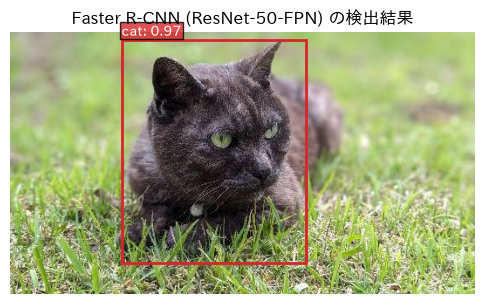

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib_fontja
import torch
from PIL import Image
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights

weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
model = fasterrcnn_resnet50_fpn(weights=weights)
model.eval()
categories = weights.meta["categories"]

img = Image.open("../sample_images/cat1.jpg").convert("RGB")
x = weights.transforms()(img)

with torch.no_grad():
    output = model([x])[0]

score_threshold = 0.5
fig, ax = plt.subplots(figsize=[6, 4])
ax.imshow(img)
for box, label, score in zip(output["boxes"], output["labels"], output["scores"]):
    if score < score_threshold:
        continue
    x0, y0, x1, y1 = box.tolist()
    ax.add_patch(patches.Rectangle((x0, y0), x1 - x0, y1 - y0, linewidth=2, edgecolor="tab:red", facecolor="none"))
    ax.text(x0, y0 - 5, f"{categories[label]}: {score:.2f}", color="white",
            bbox=dict(facecolor="tab:red", alpha=0.8, pad=1))
ax.set_title("Faster R-CNN (ResNet-50-FPN) の検出結果")
ax.axis("off")
plt.show()

## 参考文献

- Girshick, R. et al. (2014). [Rich feature hierarchies for accurate object detection and semantic segmentation](https://arxiv.org/abs/1311.2524)
- Girshick, R. (2015). [Fast R-CNN](https://arxiv.org/abs/1504.08083)
- Ren, S. et al. (2015). [Faster R-CNN: Towards Real-Time Object Detection with Region Proposal Networks](https://arxiv.org/abs/1506.01497)
- [torchvision.models.detection.fasterrcnn_resnet50_fpn — Torchvision documentation](https://docs.pytorch.org/vision/stable/models/generated/torchvision.models.detection.fasterrcnn_resnet50_fpn.html)